# 04 - LDMH Design (Proposed Method)

Implements and unit-tests the **Local Distribution Mixture Head (LDMH)** in
isolation, with NO full-image training yet. The goal here is purely to
verify: (1) shapes/gradients are correct, (2) the mixture weights genuinely
sum to 1 everywhere, (3) on a *synthetic* two-region residual field with
known ground-truth distributions, LDMH's mixture weights actually recover
the true spatial partition when optimized directly.

This is the module the paper's whole argument depends on: the global vs.
local beta mismatch (0.845 vs 1.49, Notebook 03) means a single scalar beta
can't distinguish two patches with the same beta but different underlying
mixture composition -- LDMH predicts the full local mixture instead.

In [ ]:
import sys
sys.path.insert(0, "..")

import torch
import torch.nn.functional as F
import numpy as np
from scipy import stats
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

from models.ldmh import LocalDistributionMixtureHead, mixture_gen_gaussian_nll, MixtureFiLMProjector

torch.manual_seed(42)
np.random.seed(42)


### Unit test 1 -- shapes and gradient flow

In [ ]:
ldmh = LocalDistributionMixtureHead(in_ch=1, base_ch=32, n_components=3)
x = torch.randn(2, 1, 64, 64, requires_grad=True)

mix_weights, beta, scale, feat = ldmh(x)
print("mix_weights:", mix_weights.shape, " beta:", beta.shape, " scale:", scale.shape)

loss = mixture_gen_gaussian_nll(x, mix_weights, beta, scale)
loss.backward()
print("input grad is not None:", x.grad is not None)
print("input grad norm:", x.grad.norm().item())
assert x.grad is not None and x.grad.norm().item() > 0, "Gradient did not flow -- check the forward pass."
print("PASS: shapes correct, gradients flow.")


mix_weights: torch.Size([2, 3, 64, 64])  beta: torch.Size([3])  scale: torch.Size([3])
input grad is not None: True
input grad norm: 0.016964590176939964
PASS: shapes correct, gradients flow.


### Unit test 2 -- mixture weights sum to 1 everywhere

In [ ]:
with torch.no_grad():
    mix_weights, beta, scale, feat = ldmh(torch.randn(4, 1, 96, 96))
    sums = mix_weights.sum(dim=1)
    max_dev = (sums - 1.0).abs().max().item()
    print(f"max deviation from 1.0 across all pixels/batch: {max_dev:.2e}")
    assert max_dev < 1e-5, "Mixture weights do not sum to 1 -- softmax likely misapplied."
    print("PASS: mixture weights sum to 1 everywhere (softmax is correctly applied over K).")


max deviation from 1.0 across all pixels/batch: 1.19e-07
PASS: mixture weights sum to 1 everywhere (softmax is correctly applied over K).


### Unit test 3 -- can LDMH recover a known synthetic mixture structure?

Build a synthetic residual field with two clearly different regions (a
"smooth" region with near-Gaussian residuals, a "structured" region with
heavy-tailed residuals), then directly optimize LDMH's parameters (weight
head + learned prototypes) against the mixture-NLL loss on this single
field, and check whether the learned mixture weights separate the two
regions -- i.e. whether the module can actually recover mixture structure
when it exists, before we trust it on real (noisier, less clean-cut) data.

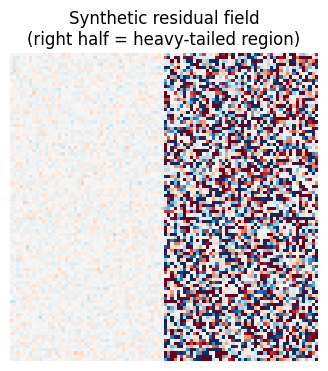

In [ ]:
SIZE = 96
region_mask = np.zeros((SIZE, SIZE), dtype=bool)
region_mask[:, SIZE//2:] = True   # right half = "structured/heavy-tailed" region

residual = np.zeros((SIZE, SIZE))
residual[~region_mask] = stats.gennorm.rvs(1.9, scale=0.03, size=(~region_mask).sum(), random_state=1)  # near-Gaussian
residual[region_mask]  = stats.gennorm.rvs(0.5, scale=0.05, size=region_mask.sum(), random_state=2)      # heavy-tailed

plt.figure(figsize=(4,4))
plt.imshow(residual, cmap="RdBu", vmin=-0.3, vmax=0.3)
plt.title("Synthetic residual field\n(right half = heavy-tailed region)")
plt.axis("off")
plt.savefig("../results/04_synthetic_residual.png", dpi=150)
plt.show()


step 50: NLL=0.2097  beta=[2.467 0.727]
step 100: NLL=0.0431  beta=[2.748 0.74 ]
step 150: NLL=-0.1120  beta=[2.784 0.776]
step 200: NLL=-0.2646  beta=[2.856 0.845]
step 250: NLL=-0.4087  beta=[2.875 0.931]
step 300: NLL=-0.5428  beta=[2.833 1.019]


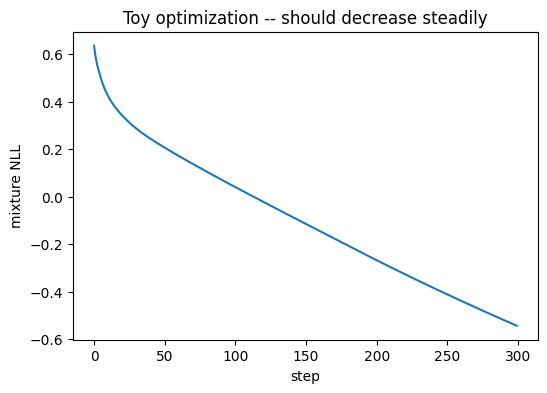

In [ ]:
ldmh_toy = LocalDistributionMixtureHead(in_ch=1, base_ch=16, n_components=2)  # K=2 matches the 2 true regions
optimizer = torch.optim.Adam(ldmh_toy.parameters(), lr=5e-3)

resid_t = torch.tensor(residual, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

dummy_input = resid_t.clone()

n_steps = 300
losses = []
for step in range(n_steps):
    optimizer.zero_grad()
    mix_weights, beta, scale, _ = ldmh_toy(dummy_input)
    loss = mixture_gen_gaussian_nll(resid_t, mix_weights, beta, scale)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (step+1) % 50 == 0:
        print(f"step {step+1}: NLL={loss.item():.4f}  beta={beta.detach().numpy().round(3)}")

plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("step"); plt.ylabel("mixture NLL")
plt.title("Toy optimization -- should decrease steadily")
plt.savefig("../results/04_toy_loss_curve.png", dpi=150)
plt.show()


Learned prototype betas: [2.832 1.021]  -> component 1 is the heaviest-tailed


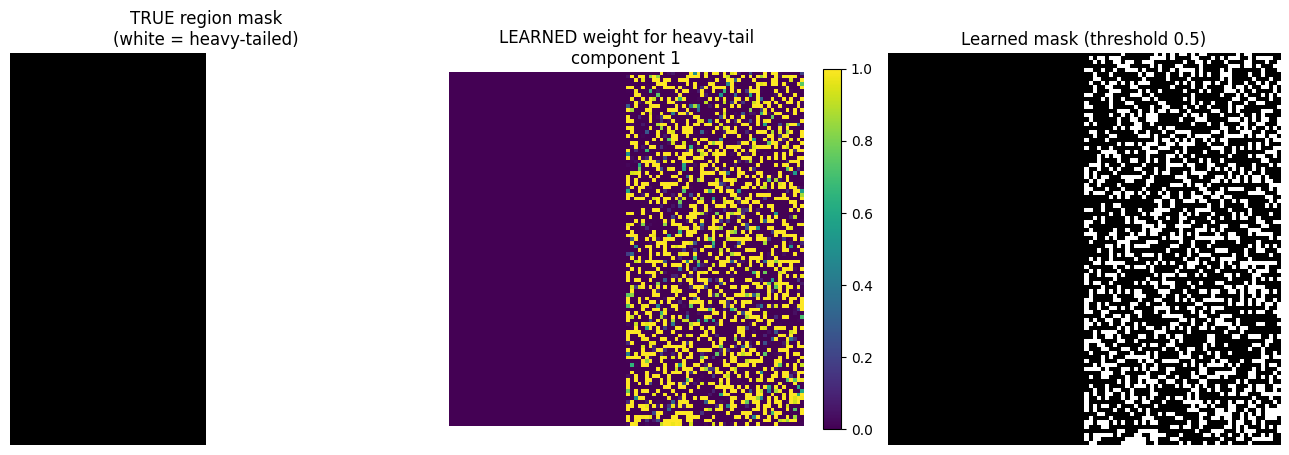

Pixel-wise agreement with true region mask: 67.4%


In [ ]:
with torch.no_grad():
    mix_weights, beta, scale, _ = ldmh_toy(dummy_input)


beta_np = beta.numpy()
heavy_component = int(np.argmin(beta_np))
print(f"Learned prototype betas: {beta_np.round(3)}  -> component {heavy_component} is the heaviest-tailed")

recovered_weight_map = mix_weights[0, heavy_component].numpy()

fig, axes = plt.subplots(1, 3, figsize=(13,4.5))
axes[0].imshow(region_mask, cmap="gray"); axes[0].set_title("TRUE region mask\n(white = heavy-tailed)"); axes[0].axis("off")
im = axes[1].imshow(recovered_weight_map, cmap="viridis", vmin=0, vmax=1)
axes[1].set_title(f"LEARNED weight for heavy-tail\ncomponent {heavy_component}"); axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046)
axes[2].imshow(recovered_weight_map > 0.5, cmap="gray"); axes[2].set_title("Learned mask (threshold 0.5)"); axes[2].axis("off")
plt.tight_layout()
plt.savefig("../results/04_recovery_check.png", dpi=150)
plt.show()

recovered_mask = recovered_weight_map > 0.5
agreement = (recovered_mask == region_mask).mean()
print(f"Pixel-wise agreement with true region mask: {agreement*100:.1f}%")
if agreement > 0.85:
    print("PASS: LDMH recovers the known synthetic mixture structure well.")
else:
    print("WARNING: recovery is weak -- consider more steps, different init, or checking the loss.")
